# Refining Pretrained Image Embeddings with EmbedKit

Pretrained image models like ResNet50 produce rich feature vectors — but those
features are general-purpose, not tuned to your downstream task. EmbedKit can
**refine** them: reshaping the embedding space to improve geometric properties
(alignment, uniformity, hubness) and, consequently, downstream kNN
classification accuracy.

This notebook walks through a complete experiment on the
[Oxford-IIIT Pets](https://www.robots.ox.ac.uk/~vgg/data/pets/) dataset:
we compare raw ResNet50 features against two flavours of refinement —
**unsupervised** (no labels) and **supervised** (labels available).

## What you'll learn

- How to extract 2048-D penultimate features from a pretrained ResNet50 and
  cache them for fast re-use.
- How to **diagnose** an embedding space with `EmbedKitAnalyzer`: intrinsic
  dimension, hubness, uniformity, and severity.
- How **unsupervised refinement** improves embedding geometry using
  self-supervised contrastive learning — no labels required.
- How **supervised refinement** directly optimises class separation using
  Supervised Contrastive Loss (SupCon) combined with Align & Uniform loss.
- How to visualise before/after embedding geometry with PCA and UMAP.

## Why refine pretrained embeddings?

A model pre-trained on ImageNet learns features that generalise across 1 000
broad categories. When you apply those features to a specific task — such as
telling apart 37 dog and cat breeds — the embedding space often has suboptimal
structure: high-dimensional **hubness** (a few "hub" points appear as
neighbours of many others), **anisotropy** (most variance concentrated in a
few directions), or **poor uniformity** (points cluster rather than spread
evenly on the hypersphere).

These pathologies hurt kNN-based retrieval and classification because distances
stop reflecting semantic similarity. Refinement learns a small projector network
that maps features into a better-shaped space — ideally one where same-class
points are close and different-class points are far, and the overall
distribution is more uniform.

The key insight is that **the backbone is frozen**; we only train a lightweight
projector (2–3 fully-connected layers) on top of the cached features.

## Setup

In [1]:
# Uncomment to install embed-kit library
# !pip install "embedkit[examples] @ git+https://github.com/fagonzalezo/embedding-kit.git"

In [2]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

from embedkit import EmbedKit, EmbedKitAnalyzer
from embedkit.improvement import (
    AlignUniformLoss,
    CompositeAugmentation,
    CombinedLoss,
    EmbeddingRefiner,
    FeatureDropout,
    GaussianNoise,
    SupConLoss,
    Trainer,
)
from embedkit.visualization.embedding_viz import EmbeddingVisualizer

# Device auto-detection
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

Using device: mps


## The experiment in three stages

| Stage | What changes | Labels used? |
|---|---|---|
| **Raw** | ResNet50 features as-is | — |
| **Unsupervised** | EmbedKit self-supervised refiner | No |
| **Supervised** | EmbedKit SupCon + AlignUniform refiner | Yes |

The downstream evaluation is identical in all three stages: a kNN classifier
with `k=5` trained on the (possibly refined) training embeddings and evaluated
on the test embeddings. Only the embedding changes.

---
## Step 1 — Feature extraction

**ResNet50** is a deep convolutional network with ~25 M parameters, pre-trained
on ImageNet-1K. Its penultimate layer — the output of the global average
pooling before the final classification head — produces a **2048-dimensional**
feature vector that summarises the image content.

We replace the final `fc` layer with `nn.Identity()` so the forward pass
returns those 2048-D features directly. The backbone is frozen (`eval()` mode,
`torch.no_grad()`).

**Oxford-IIIT Pets** has 37 breeds (25 dog + 12 cat), ~3 680 training images
and ~3 669 test images (224×224 colour). It is a *fine-grained* benchmark:
breeds within a species look very similar, so the embedding geometry matters
more than on coarse datasets like CIFAR-10.

In [3]:
CACHE = Path("data/pets_resnet50.npz")


def extract_or_load(cache_path: Path):
    """Return (X_train, y_train, X_test, y_test) as float32 numpy arrays."""
    if cache_path.exists():
        print(f"Loading cached embeddings from {cache_path}")
        d = np.load(cache_path)
        return d["X_train"], d["y_train"], d["X_test"], d["y_test"]

    print("Cache not found — downloading Pets and extracting ResNet50 features ...")
    print("(This may take several minutes on first run.)\n")

    try:
        from torchvision import datasets, models, transforms
    except ImportError as e:
        raise ImportError(
            "torchvision is required.\n"
            "Install with: pip install -e '.[examples]'"
        ) from e

    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    data_root = cache_path.parent
    data_root.mkdir(parents=True, exist_ok=True)

    train_ds = datasets.OxfordIIITPet(
        root=data_root, split="trainval", download=True, transform=transform
    )
    test_ds = datasets.OxfordIIITPet(
        root=data_root, split="test", download=True, transform=transform
    )

    backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    backbone.fc = nn.Identity()
    backbone = backbone.to(device).eval()

    def run_extraction(dataset, desc):
        loader = torch.utils.data.DataLoader(
            dataset, batch_size=64, num_workers=4, pin_memory=(device != "cpu")
        )
        features, labels = [], []
        with torch.no_grad():
            for i, (imgs, lbls) in enumerate(loader):
                feats = backbone(imgs.to(device))
                features.append(feats.cpu().numpy())
                labels.append(lbls.numpy())
                if (i + 1) % 10 == 0:
                    print(f"  {desc}: {(i + 1) * loader.batch_size}/{len(dataset)}",
                          end="\r")
        print()
        return (
            np.concatenate(features).astype(np.float32),
            np.concatenate(labels),
        )

    X_train, y_train = run_extraction(train_ds, "train")
    X_test,  y_test  = run_extraction(test_ds,  "test ")

    np.savez_compressed(
        cache_path,
        X_train=X_train, y_train=y_train,
        X_test=X_test,   y_test=y_test,
    )
    print(f"Saved embeddings to {cache_path}\n")
    return X_train, y_train, X_test, y_test

In [4]:
X_train, y_train, X_test, y_test = extract_or_load(CACHE)

print(f"Train embeddings : {X_train.shape}  (n_samples × n_features)")
print(f"Test  embeddings : {X_test.shape}")
print(f"Classes          : {len(np.unique(y_train))}")

Loading cached embeddings from data/pets_resnet50.npz
Train embeddings : (3680, 2048)  (n_samples × n_features)
Test  embeddings : (3669, 2048)
Classes          : 37


---
## Step 2 — Diagnosing the raw embedding space

`EmbedKitAnalyzer` is the diagnostic tool in EmbedKit. Think of it as a
"blood test" for your embedding space. It reports four families of metrics:

| Metric | What it measures | Healthy range |
|---|---|---|
| **Intrinsic dimension** (TwoNN) | Effective dimensionality of the manifold | Much lower than `n_features` |
| **k-skewness** (hubness) | How unevenly points appear as kNN neighbours | Close to 0 |
| **Uniformity** | How evenly points spread on the unit hypersphere | Close to 0 (less negative) |
| **Severity** | Overall summary (low / medium / high) | low |

High hubness means a few "hub" points are returned as a neighbour for almost
everyone — they drown out genuine nearest neighbours and hurt retrieval
accuracy. High anisotropy (low uniformity) means the space wastes dimensions
and makes distances less meaningful.

In [5]:
print("=== Raw ResNet50 embeddings — diagnostic report ===")
report_raw = EmbedKitAnalyzer().fit(X_train)
report_raw.print_summary()

=== Raw ResNet50 embeddings — diagnostic report ===

  EmbedKit Analysis Report  (3680 samples × 2048 dims)

[Intrinsic Dimension]
  consensus ID     : 14.51  (±11.17)
  TwoNN         : 16.15
  MLE           : 12.86
  lPCA          : 38.00
  MOM           : 9.38

[Hubness]
  k-skewness       : 1.285
  Robin Hood index : -0.508
  hub ratio        : 0.152
  antihub ratio    : 0.057
  hub contamination: 0.522

[Geometry]
  participation_ratio : 45.46
  isotropy_score      : 0.238
  relative_contrast   : 1.579
  neighbor_consistency: 0.998
  uniformity          : -3.1425

[Kernel]
  sigma            : 13.1289
  effective_rank   : 4.72
  spectral_gap     : 22.432
  condition_number : 5.41e+02

[Recommendations]  severity=HIGH
  • Low intrinsic-to-ambient ratio (ID/D ≈ 0.01): the embedding is very sparse — strong dimensionality reduction is advised.
  • Low participation ratio (45.5 << 2048): embeddings are highly anisotropic. Consider whitening or applying an alignment loss.

[Auto-config]


In [6]:
knn_raw = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
acc_raw = knn_raw.score(X_test, y_test)
print(f"Raw kNN accuracy (k=5): {acc_raw:.3f}")

Raw kNN accuracy (k=5): 0.898


---
## Step 3 — Unsupervised refinement

The unsupervised refiner uses **self-supervised contrastive learning**: it
creates two augmented views of each embedding (Gaussian noise + feature
dropout) and trains a projector to make the two views of the *same* sample
close while pushing apart views from *different* samples.

No class labels are needed — the model learns purely from the structure of the
data. The goal is improved **geometry** (lower hubness, higher uniformity),
which in turn makes kNN distances more reliable.

Because class information is never seen, classification gains are typically
modest (+0–2 pp) — but the improvement in diagnostic metrics can be
substantial, and the refiner is useful in any setting where labels are absent.

`target_dim="auto"` lets EmbedKit pick the output dimension from the analyzer
report (based on estimated intrinsic dimension).

In [7]:
print("Training unsupervised refiner ...")
ek = EmbedKit(
    mode="self_supervised",
    target_dim="auto",
    epochs=80,
    eval_every=20,
    device=device,
)
X_train_u = ek.fit_transform(X_train)
X_test_u  = ek.transform(X_test)
print(f"Refined shape: {X_train_u.shape}")

Training unsupervised refiner ...
Refined shape: (3680, 22)


In [8]:
print("=== Unsupervised-refined embeddings — diagnostic report ===")
report_u = EmbedKitAnalyzer().fit(X_train_u)
report_u.print_summary()

knn_u = KNeighborsClassifier(n_neighbors=5).fit(X_train_u, y_train)
acc_u = knn_u.score(X_test_u, y_test)
print(f"Unsupervised refined kNN accuracy (k=5): {acc_u:.3f}  ({(acc_u - acc_raw)*100:+.1f}% vs raw)")

=== Unsupervised-refined embeddings — diagnostic report ===

  EmbedKit Analysis Report  (3680 samples × 22 dims)

[Intrinsic Dimension]
  consensus ID     : 5.43  (±7.37)
  TwoNN         : 6.41
  MLE           : 4.36
  lPCA          : 22.00
  MOM           : 4.46

[Hubness]
  k-skewness       : 0.501
  Robin Hood index : -0.174
  hub ratio        : 0.004
  antihub ratio    : 0.000
  hub contamination: 0.054

[Geometry]
  participation_ratio : 20.19
  isotropy_score      : 0.953
  relative_contrast   : 1.278
  neighbor_consistency: 0.992
  uniformity          : -3.4917

[Kernel]
  sigma            : 1.4226
  effective_rank   : 6.28
  spectral_gap     : 28.241
  condition_number : 9.74e+02

[Recommendations]  severity=LOW
  • Moderate intrinsic-to-ambient ratio (ID/D ≈ 0.25): dimensionality reduction may improve downstream tasks.

[Auto-config]
  suggested_k          : 30
  suggested_sigma      : 1.4226
  suggested_target_dim : 8

Unsupervised refined kNN accuracy (k=5): 0.899  (+0.1% v

---
## Step 4 — Supervised refinement

When class labels are available, we can directly optimise for class separation
using **Supervised Contrastive Loss (SupCon)**:

- Pairs of same-class embeddings are attracted.
- All cross-class pairs are repelled.

SupCon alone can collapse the geometry (everything pushed to a few tight
clusters). We combine it with **AlignUniform loss**, which adds a uniformity
penalty encouraging the projections to spread evenly on the unit hypersphere.

```
L = SupCon(τ=0.07)  +  0.3 × AlignUniform
```

The projector maps 2048 → 512 (hidden) → 128 (output). We use the low-level
EmbedKit API so each component is explicit and individually swappable.

In [9]:
aug = CompositeAugmentation([GaussianNoise(std=0.05), FeatureDropout(p=0.1)])
loss_fn = CombinedLoss([
    (SupConLoss(temperature=0.07), 1.0),
    (AlignUniformLoss(), 0.3),
])
model = EmbeddingRefiner(input_dim=2048, target_dim=22, hidden_dim=512, n_layers=2)

trainer = Trainer(
    model=model,
    augmentation=aug,
    loss=loss_fn,
    epochs=80,
    batch_size=128,
    optimizer="adam",
    lr=3e-4,
    scheduler="cosine",
    eval_every=20,
    eval_metrics=["uniformity", "k_skewness"],
    device=device,
    random_state=42,
)

In [10]:
print("Training supervised refiner ...")
trainer.fit(X_train, y=y_train)

Training supervised refiner ...


In [11]:
X_train_s = trainer.transform(X_train)
X_test_s  = trainer.transform(X_test)

print("=== Supervised-refined embeddings — diagnostic report ===")
report_s = EmbedKitAnalyzer(id_methods=["TwoNN"]).fit(X_train_s)
report_s.print_summary()

knn_s = KNeighborsClassifier(n_neighbors=5).fit(X_train_s, y_train)
acc_s = knn_s.score(X_test_s, y_test)
print(f"Supervised refined kNN accuracy (k=5): {acc_s:.3f}  ({(acc_s - acc_raw)*100:+.1f}% vs raw)")

=== Supervised-refined embeddings — diagnostic report ===

  EmbedKit Analysis Report  (3680 samples × 22 dims)

[Intrinsic Dimension]
  consensus ID     : 12.44  (±0.00)
  TwoNN         : 12.44

[Hubness]
  k-skewness       : 0.816
  Robin Hood index : -0.370
  hub ratio        : 0.096
  antihub ratio    : 0.002
  hub contamination: 0.307

[Geometry]
  participation_ratio : 19.86
  isotropy_score      : 0.937
  relative_contrast   : 1.283
  neighbor_consistency: 0.939
  uniformity          : -3.1055

[Kernel]
  sigma            : 1.4208
  effective_rank   : 6.99
  spectral_gap     : 28.789
  condition_number : 3.09e+04

[Recommendations]  severity=LOW
  • No major issues detected. Embedding geometry looks healthy.

[Auto-config]
  suggested_k          : 30
  suggested_sigma      : 1.4208
  suggested_target_dim : 19

Supervised refined kNN accuracy (k=5): 0.928  (+3.0% vs raw)


---
## Step 5 — Visualising the geometry change

Improved metrics should be visible in 2-D projections: tighter intra-class
clusters and larger inter-class margins. We use two projection methods:

- **PCA** — linear, fast, preserves global variance structure.
- **UMAP** — non-linear, preserves local neighbourhood structure (better for
  revealing cluster quality).

Both plots show *training* embeddings coloured by class label. Compare the
before/after columns: raw (left) vs refined (right).

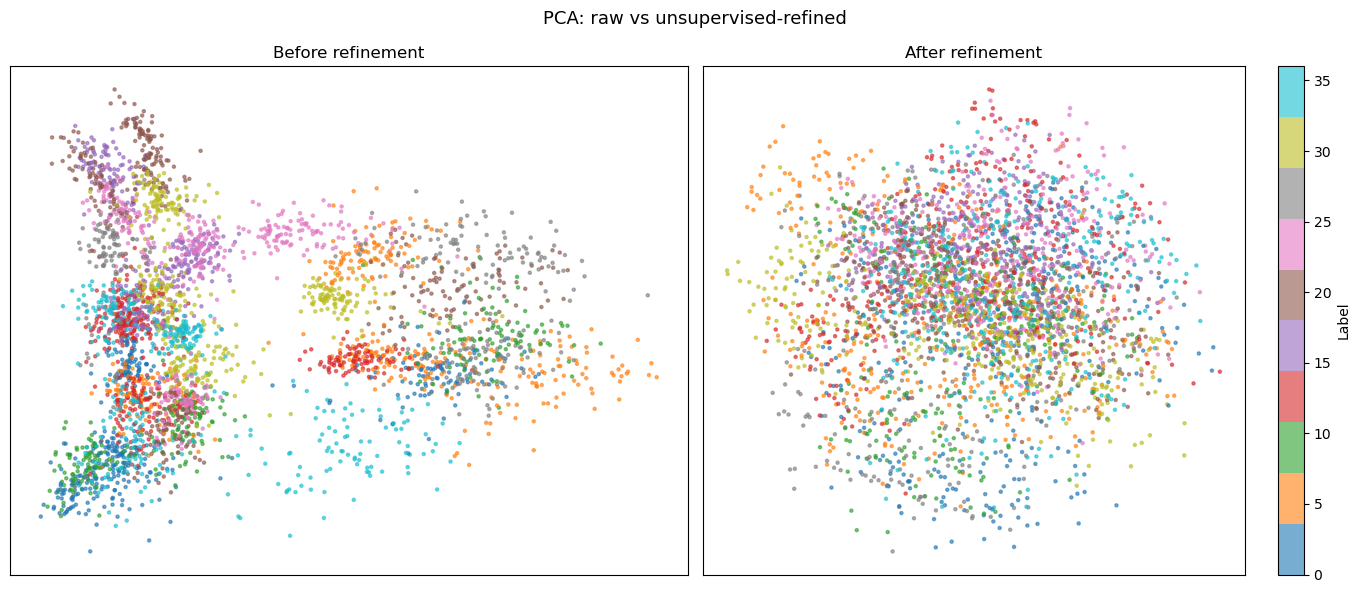

In [18]:
viz_pca = EmbeddingVisualizer(method="pca", random_state=0)
fig_pca = viz_pca.plot_comparison(X_train, X_train_u, labels=y_train)
fig_pca.suptitle("PCA: raw vs unsupervised-refined", fontsize=13)
plt.tight_layout()
plt.show()

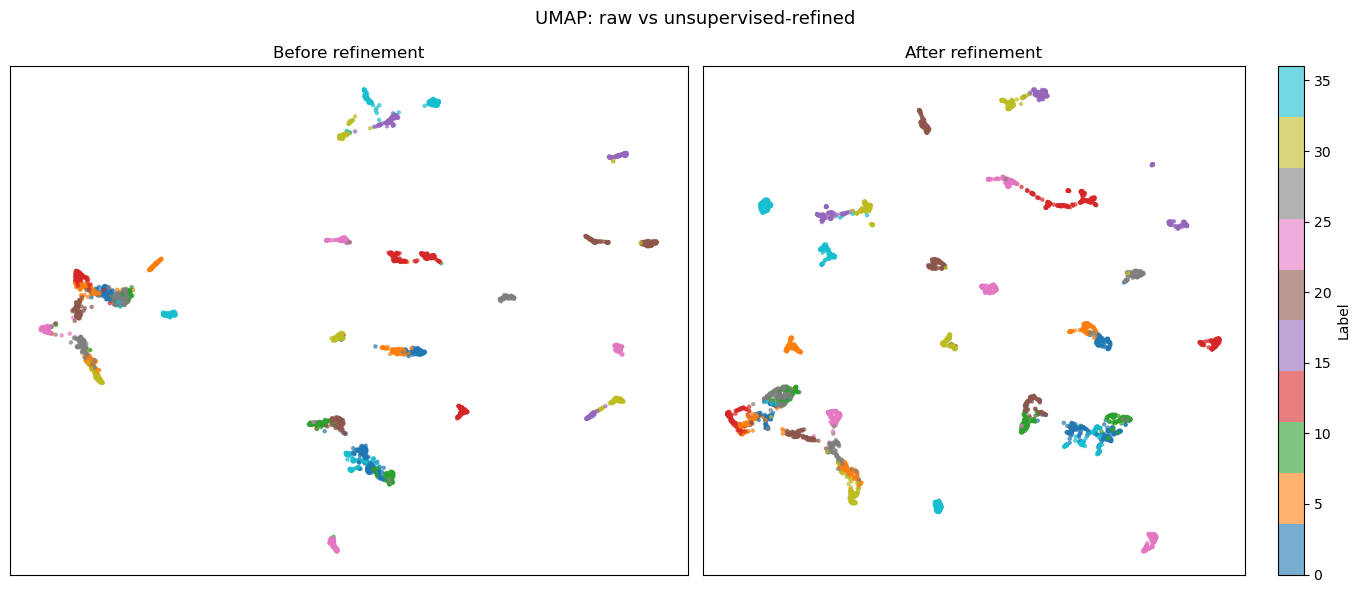

In [19]:
viz_umap = EmbeddingVisualizer(method="umap", random_state=0)
fig_umap = viz_umap.plot_comparison(X_train, X_train_u, labels=y_train)
fig_umap.suptitle("UMAP: raw vs unsupervised-refined", fontsize=13)
plt.tight_layout()
plt.show()

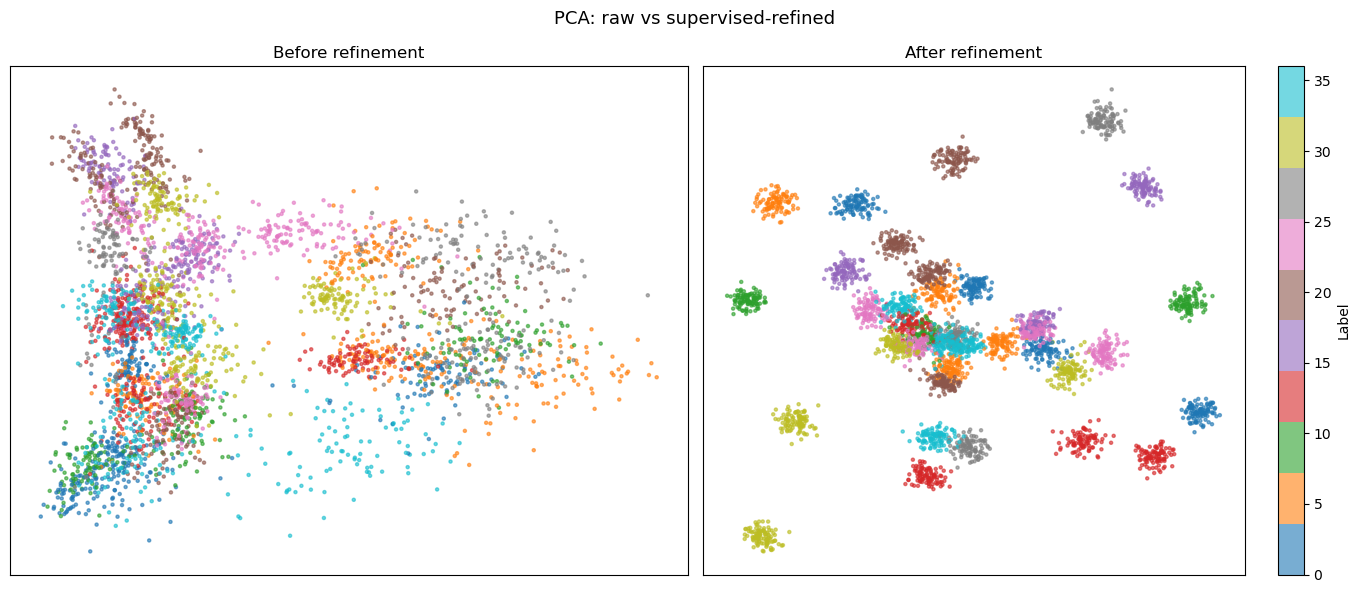

In [20]:
viz_pca = EmbeddingVisualizer(method="pca", random_state=0)
fig_pca = viz_pca.plot_comparison(X_train, X_train_s, labels=y_train)
fig_pca.suptitle("PCA: raw vs supervised-refined", fontsize=13)
plt.tight_layout()
plt.show()

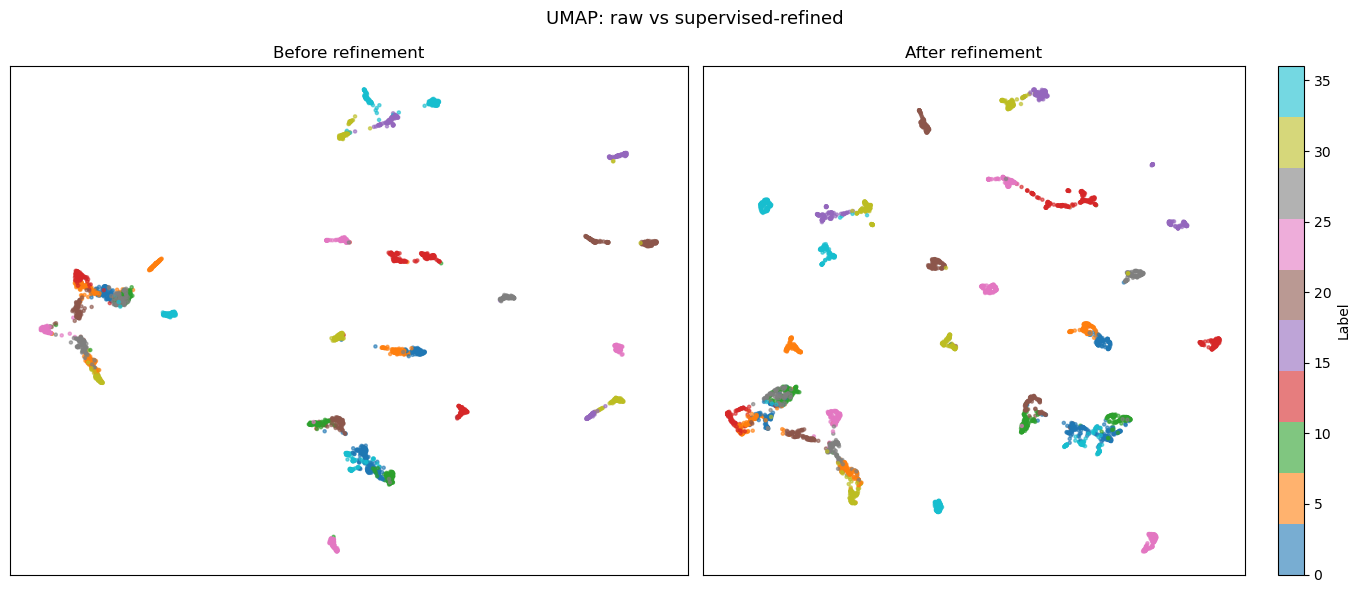

In [21]:
viz_umap = EmbeddingVisualizer(method="umap", random_state=0)
fig_umap = viz_umap.plot_comparison(X_train, X_train_u, labels=y_train)
fig_umap.suptitle("UMAP: raw vs supervised-refined", fontsize=13)
plt.tight_layout()
plt.show()

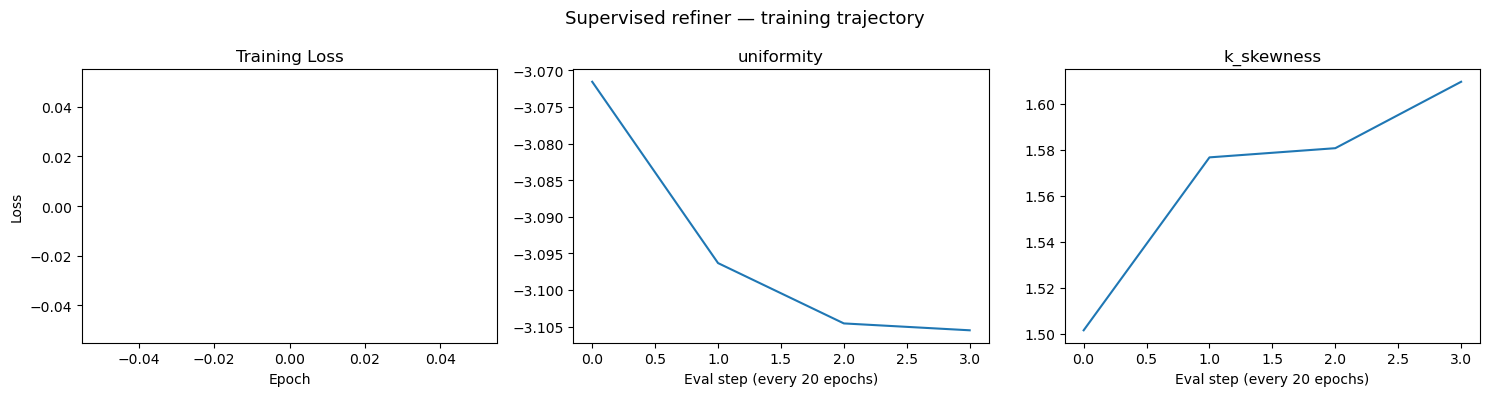

In [14]:
fig_traj = viz_pca.plot_training_trajectory(trainer.history)
fig_traj.suptitle("Supervised refiner — training trajectory", fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 6 — Results summary

The table below compares all three embedding variants on the **same** test set,
**same** kNN classifier (`k=5`), **same** random split. The only variable is
the embedding fed to kNN.

In [15]:
header = f"{'Stage':<30} {'Dim':>6}  {'Acc':>6}  {'Delta':>7}"
sep    = "-" * 55
print(header)
print(sep)
print(f"{'Raw ResNet50':<30} {X_train.shape[1]:>6}  {acc_raw:>6.3f}  {'—':>7}")
print(f"{'Unsupervised refinement':<30} {X_train_u.shape[1]:>6}  {acc_u:>6.3f}  {(acc_u - acc_raw)*100:>+6.1f}%")
print(f"{'Supervised refinement':<30} {X_train_s.shape[1]:>6}  {acc_s:>6.3f}  {(acc_s - acc_raw)*100:>+6.1f}%")

Stage                             Dim     Acc    Delta
-------------------------------------------------------
Raw ResNet50                     2048   0.898        —
Unsupervised refinement            22   0.899    +0.1%
Supervised refinement              22   0.928    +3.0%


## Discussion

**Unsupervised gains** primarily reflect improved geometry: lower hubness
(`k_skewness` closer to 0) and higher uniformity. kNN accuracy improvements
are typically modest on a fine-grained dataset with strong pretrained features,
because the refiner cannot know which dimensions are class-discriminative.
Even a small accuracy gain here is a useful bonus — the main story is the
geometry improvement visible in the diagnostic report.

**Supervised gains** are larger because SupCon directly maximises class
separation. The projector learns to allocate its 128 output dimensions
to the most class-discriminative directions, discarding irrelevant variation
(individual pet pose, lighting, background). The result is a space where
nearest neighbours are much more likely to share the same breed label.

**When to choose which:**
- No labels available → unsupervised refinement improves geometry and often
  gives a modest accuracy lift.
- Labels available → supervised refinement; the gain scales with label quality
  and number of classes.
- Both can be combined: first unsupervised pre-training, then fine-tune with
  labels.

## Next steps

- **Different backbone** — try CLIP (`open_clip`) or DINOv2 (`torch.hub`) for
  stronger baselines; the refinement story still applies.
- **Stronger domain shift** — use EuroSAT (satellite imagery) with a ResNet50
  backbone for a larger refinement headroom and more dramatic gains.
- **Different losses** — swap in `NTXentLoss` (NT-Xent / SimCLR) or
  `TripletLoss` and compare. See `embedkit/improvement/losses/`.
- **Analysis-only workflow** — see `examples/01_analysis.py` for a standalone
  tour of `EmbedKitAnalyzer` metrics on synthetic data.
- **High-level API** — `examples/02_self_supervised.py` shows the one-liner
  `EmbedKit(mode="self_supervised").fit_transform(X)` for quick experimentation.